"""
This script is used to plot the Global mean surface air temperature (GMSAT) from observation and multimodel simulation.
"""

## import observation data

In [1]:
import sys, pathlib
# point this to your project root (the folder that contains "src/")
project_root = pathlib.Path.cwd()  # or pathlib.Path("/path/to/your/project")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
 
import importlib.util
print("find_spec('src') ->", importlib.util.find_spec("src"))

find_spec('src') -> ModuleSpec(name='src', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f14b1c125e0>, origin='/work/mh0033/m301036/OBS_LPS_revision/src/__init__.py', submodule_search_locations=['/work/mh0033/m301036/OBS_LPS_revision/src'])


In [2]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from pathlib import Path
import glob
import os
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess
from src.plot_func import *
# %%
# import importlib
# importlib.reload(src.plot_func)
# call once at the start of your script / notebook:
set_science_advances_style(column='double')  # or 'single'

In [3]:
# subplot a: global mean temperature anomalies during 1850-2022 HadCRUT5
input_observation = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG1/'

tas_HadCRUT_annual = xr.open_dataset(input_observation + 'tas_HadCRUT5_annual_anomalies.nc')

In [4]:
tas_HadCRUT_annual

<xarray.Dataset>
Dimensions:  (lon: 180, lat: 90, year: 173)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2018 2019 2020 2021 2022
Data variables:
    tas      (year, lat, lon) float64 ...

In [5]:
tas_HadCRUT_annual_1850_2022 = tas_HadCRUT_annual.sel(year=slice('1993', '2022')).tas

In [6]:
tas_HadCRUT5_annual_ano = tas_HadCRUT_annual_1850_2022.mean(dim=['year'])

In [7]:
tas_HadCRUT5_annual_ano.min().values, tas_HadCRUT5_annual_ano.max().values

(array(-0.39887073), array(2.23875029))

In [8]:
dir_obs_in = "/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG1/"
tas_HadCRUT5_annual_global = xr.open_dataset(dir_obs_in+'tas_HadCRUT5_global_annual_mean_timeseries.nc')
tas_NOAA_annual_global = xr.open_dataset(dir_obs_in+'tas_NOAA_global_annual_mean_timeseries.nc')
tas_Berkeley_annual_global = xr.open_dataset(dir_obs_in+'tas_Berkeley_global_annual_mean_timeseries.nc')

In [9]:
tas_HadCRUT5_annual_global.min().values, tas_HadCRUT5_annual_global.max().values

(<bound method Mapping.values of <xarray.Dataset>
 Dimensions:  ()
 Data variables:
     tas      float64 -0.6048>,
 <bound method Mapping.values of <xarray.Dataset>
 Dimensions:  ()
 Data variables:
     tas      float64 0.9201>)

## Input the multimodel mean GMST data

### Subplot b: plot the multimodel ensemble mean timeseries

In [10]:
input_model = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/LE_timeseries/'

ACCESS_GMSAT_annual_ENS     = xr.open_dataset(input_model + 'GMSAT_ACCESS_annual_timeseries_ENS.nc')
CESM2_GMSAT_annual_ENS      = xr.open_dataset(input_model + 'GMSAT_CESM2LE_CMIP6_SMBB_annual_timeseries_ENS.nc')
CanESM_GMSAT_annual_ENS     = xr.open_dataset(input_model + 'GMSAT_CanESM5_annual_timeseries_ENS.nc')
EC_Earth_GMSAT_annual_ENS   = xr.open_dataset(input_model + 'GMSAT_EC_Earth_annual_timeseries_ENS.nc')
IPSL_GMSAT_annual_ENS       = xr.open_dataset(input_model + 'GMSAT_IPSL_CM6A_annual_timeseries_ENS.nc')
MIROC_GMSAT_annual_ENS      = xr.open_dataset(input_model + 'GMSAT_MIROC6_annual_timeseries_ENS.nc')
MPI_GMSAT_annual_ENS        = xr.open_dataset(input_model + 'GMSAT_MPI_ESM_annual_timeseries_ENS.nc')
MMEM_GMSAT_annual_ENS       = xr.open_dataset(input_model + 'GMSAT_SMILEs_ENS_annual_timeseries_obtained_basedOn_ModelENS_CESM2_100realizations.nc')

### Subplot c: plotting the alpha and beta coefficients spatial pattern

In [11]:
# load the data
input_observation = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100/'

HadCRUT5_MMLE = xr.open_dataset(input_observation + 'OBS_SAT_anomaly_partition_wrt_MMLE_ENS.nc')

beta_MMEM_HadCRUT5_annual = HadCRUT5_MMLE['slope']
alpha_MMEM_HadCRUT5_annual = HadCRUT5_MMLE['intercept']

In [12]:
dir_MMEM = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG1/Fingerprint/cesm2_100/'
MMEM_beta_pattern = xr.open_dataset(dir_MMEM+'MMEM_GSAT_slope_Beta_coefficients_1850_2022.nc')

In [13]:
MMEM_beta_pattern

<xarray.Dataset>
Dimensions:       (lat: 90, lon: 180)
Coordinates:
  * lat           (lat) float64 -89.0 -87.0 -85.0 -83.0 ... 83.0 85.0 87.0 89.0
  * lon           (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    coefficients  (lat, lon) float64 ...

### Subplot d: the reconstructed y mean and the y residual from the raw data

In [14]:
GSAT_estimate_forced = HadCRUT5_MMLE['forced_signal']
GSAT_estimate_internal = HadCRUT5_MMLE['internal_variability']

In [15]:
# Calculate the last 30years mean
GSAT_estimate_forced_1993_2022 = GSAT_estimate_forced.sel(year=slice('1993', '2022'))

In [16]:
# Calculate the last 30years mean
GSAT_estimate_forced_1979_2022 = GSAT_estimate_forced.sel(year=slice('1979', '2022'))

In [17]:
GSAT_estimate_forced_mean = GSAT_estimate_forced_1993_2022.mean(dim=['year'])
GSAT_estimate_forced_1979_mean =GSAT_estimate_forced_1979_2022.mean(dim=['year'])

In [18]:
GSAT_estimate_forced_mean.min().values, GSAT_estimate_forced_mean.max().values

(array(-0.38939427), array(2.2474272))

In [19]:
GSAT_estimate_forced_1979_mean

<xarray.DataArray 'forced_signal' (lat: 90, lon: 180)>
array([[0.23496026, 0.23496117, 0.23541162, ..., 0.23503136, 0.23503028,
        0.23495936],
       [0.22503026, 0.22536386, 0.22580275, ..., 0.22430193, 0.22447983,
        0.22469666],
       [0.18596164, 0.18728689, 0.18873719, ..., 0.18245338, 0.18351149,
        0.18463638],
       ...,
       [1.63565009, 1.64258654, 1.64794838, ..., 1.6156283 , 1.62249139,
        1.62871364],
       [1.65874612, 1.66263905, 1.66596024, ..., 1.64768866, 1.65158248,
        1.65485318],
       [1.66417608, 1.66420861, 1.67251809, ..., 1.65629455, 1.65632697,
        1.66414356]])
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

### Subplot e: the MMLE SAT anomalies during 1993-2022

In [20]:
dir_MMLE = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/LE_data/LE_ensemble_mean/'
MMLE_ds = xr.open_dataset(dir_MMLE + 'SMILEs_annual_ano_1850_2022_smbbCESM2_complement.nc')
MMLE_ds

<xarray.Dataset>
Dimensions:  (lon: 180, lat: 90, year: 173)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2018 2019 2020 2021 2022
    height   float64 ...
Data variables:
    tas      (year, lat, lon) float32 ...

In [21]:
MMLE_30yr_mean = MMLE_ds.sel(year=slice('1993', '2022')).tas.mean(dim=['year'])

In [22]:
MMLE_30yr_mean

<xarray.DataArray 'tas' (lat: 90, lon: 180)>
array([[0.68930334, 0.6893955 , 0.6902774 , ..., 0.68668467, 0.6872307 ,
        0.6878815 ],
       [0.6741712 , 0.6746145 , 0.6750403 , ..., 0.6719487 , 0.6725851 ,
        0.6733233 ],
       [0.67173743, 0.6754499 , 0.6779598 , ..., 0.6619297 , 0.66544175,
        0.6690219 ],
       ...,
       [2.070448  , 2.0723772 , 2.0749576 , ..., 2.0645316 , 2.0664182 ,
        2.0683033 ],
       [2.0788872 , 2.0798752 , 2.0807693 , ..., 2.0756469 , 2.0766437 ,
        2.0777032 ],
       [2.0882864 , 2.0882213 , 2.0888598 , ..., 2.086209  , 2.0868015 ,
        2.087552  ]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
    height   float64 ...

In [23]:
MMLE_1979_mean = MMLE_ds.sel(year=slice('1979', '2022')).tas.mean(dim=['year'])

In [24]:
Forced_anomalies_diff = MMLE_1979_mean - GSAT_estimate_forced_1979_mean

In [25]:
MMLE_1979_mean

<xarray.DataArray 'tas' (lat: 90, lon: 180)>
array([[0.52238864, 0.5223817 , 0.5230904 , ..., 0.52038664, 0.5208242 ,
        0.52123183],
       [0.5097674 , 0.5101047 , 0.51042384, ..., 0.5080457 , 0.50856787,
        0.5091327 ],
       [0.50741524, 0.5101378 , 0.51218146, ..., 0.49978495, 0.5024215 ,
        0.50509775],
       ...,
       [1.5232017 , 1.524734  , 1.5266117 , ..., 1.5185878 , 1.5200953 ,
        1.5215542 ],
       [1.529244  , 1.530037  , 1.5307612 , ..., 1.5267472 , 1.5274993 ,
        1.5283221 ],
       [1.5350465 , 1.5349967 , 1.535419  , ..., 1.5336455 , 1.5340323 ,
        1.5345402 ]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
    height   float64 ...

In [26]:
Forced_anomalies_diff_1993 = MMLE_30yr_mean - GSAT_estimate_forced_mean

In [27]:
Forced_anomalies_diff_1993

<xarray.DataArray (lat: 90, lon: 180)>
array([[0.39318008, 0.39327104, 0.39357806, ..., 0.39049047, 0.39103777,
        0.39175945],
       [0.39038638, 0.39041349, 0.39029171, ..., 0.3890756 , 0.38948831,
        0.38995461],
       [0.4364978 , 0.43857652, 0.43929691, ..., 0.4310111 , 0.43322095,
        0.43541603],
       ...,
       [0.06064606, 0.05415583, 0.05020456, ..., 0.0794537 , 0.07297069,
        0.06692099],
       [0.04047323, 0.03679307, 0.03349133, ..., 0.05080124, 0.04713041,
        0.04395742],
       [0.04285605, 0.04275227, 0.03373854, ..., 0.05013347, 0.05068748,
        0.04216041]])
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
    height   float64 ...

In [28]:
# # dir_1979_out = "/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS2_Satellite/"
# dir_output = "/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG1/plot_data_update_Jan07/"
# os.makedirs(dir_output, exist_ok=True)
# MMLE_1979_mean.to_dataset(name="tas").to_netcdf(dir_output+'MMLE_1979_2022_total_SAT_anomalies.nc')
# GSAT_estimate_forced_1979_mean.to_dataset(name="forced_signal").to_netcdf(dir_output+'OBS_1979_2022_SAT_forced_anomalies.nc')
# Forced_anomalies_diff.to_dataset(name="Forced_anomalies_diff").to_netcdf(dir_output + 'MMEM_GSAT_Forced_anomalies_diff_1979_2022.nc')

In [29]:
Forced_anomalies_diff

<xarray.DataArray (lat: 90, lon: 180)>
array([[ 0.28742838,  0.28742056,  0.2876788 , ...,  0.28535528,
         0.28579391,  0.28627247],
       [ 0.28473715,  0.28474085,  0.28462109, ...,  0.28374374,
         0.28408804,  0.28443602],
       [ 0.3214536 ,  0.32285091,  0.32344428, ...,  0.31733157,
         0.31891001,  0.32046137],
       ...,
       [-0.11244838, -0.11785252, -0.1213367 , ..., -0.09704047,
        -0.10239604, -0.10715941],
       [-0.12950217, -0.13260201, -0.135199  , ..., -0.12094143,
        -0.12408316, -0.12653108],
       [-0.12912963, -0.12921186, -0.13709911, ..., -0.12264904,
        -0.12229462, -0.12960338]])
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
    height   float64 ...

## Plotting 

In [30]:
import svgwrite
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.legend import Legend
import matplotlib.lines as Line2D

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap

In [31]:
# Setting the range of the x-axis
x = np.arange(1850, 2023, 1)

In [32]:
obs_name = ["HadCRUT5", "NOAAGlobalTemp", "BerkeleyEarth"]
model_names = ["CanESM5(50)", "CESM2(100)", "IPSL-CM6A-LR(32)", "EC-Earth3(21)", "ACCESS-ESM1.5(40)", "MPI-ESM1.2-LR(50)","MIROC6(50)"]

RGB_dict = {'CanESM5(50)':np.array([50, 34, 136])/255., 
            'IPSL-CM6A-LR(32)':np.array([68, 170, 152])/255., 
            'EC-Earth3(21)':np.array([221, 204, 118])/255., 
            'ACCESS-ESM1.5(40)':np.array([204, 101, 119])/255.,
            'MPI-ESM1.2-LR(50)':np.array([170, 67, 153])/255., 
            'MIROC6(50)':np.array([136, 33, 85])/255., 
            'MMLE':np.array([0, 0, 0])/255.}

RGB_dict = {'CanESM5(50)':'#A60E16', 
            'CESM2(100)':'#EE3B2A',
            'IPSL-CM6A-LR(32)':'#FC9171', 
            'EC-Earth3(21)':"#F5BFA2", 
            'ACCESS-ESM1.5(40)':"#5FB7B5",
            'MPI-ESM1.2-LR(50)':"#246BA1", 
            'MIROC6(50)':"#073278", 
            'MMLE':'black'}

In [53]:
c_obs = "orange"
c_obs_1 = "blue"
c_obs_2 = "green" #'darkred'

obs_color = {
    "NOAAGlobalTemp": c_obs,
    "HadCRUT5": c_obs_1,
    "BerkeleyEarth": c_obs_2
}

for obs in obs_name:
    print(obs)
    obs_color[obs]
    print(obs_color[obs])
    
lw_obs = 2.5
lw_model = 4.5
xmin, xmax = 1850, 2022
ymin, ymax = -1.5, 2.0

HadCRUT5
blue
NOAAGlobalTemp
orange
BerkeleyEarth
green


In [57]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable
#  cmap = mcolors.ListedColormap(palettable.scientific.diverging.Vik_20.mpl_colors)
cmap=mcolors.ListedColormap(palettable.cmocean.diverging.Balance_20.mpl_colors)

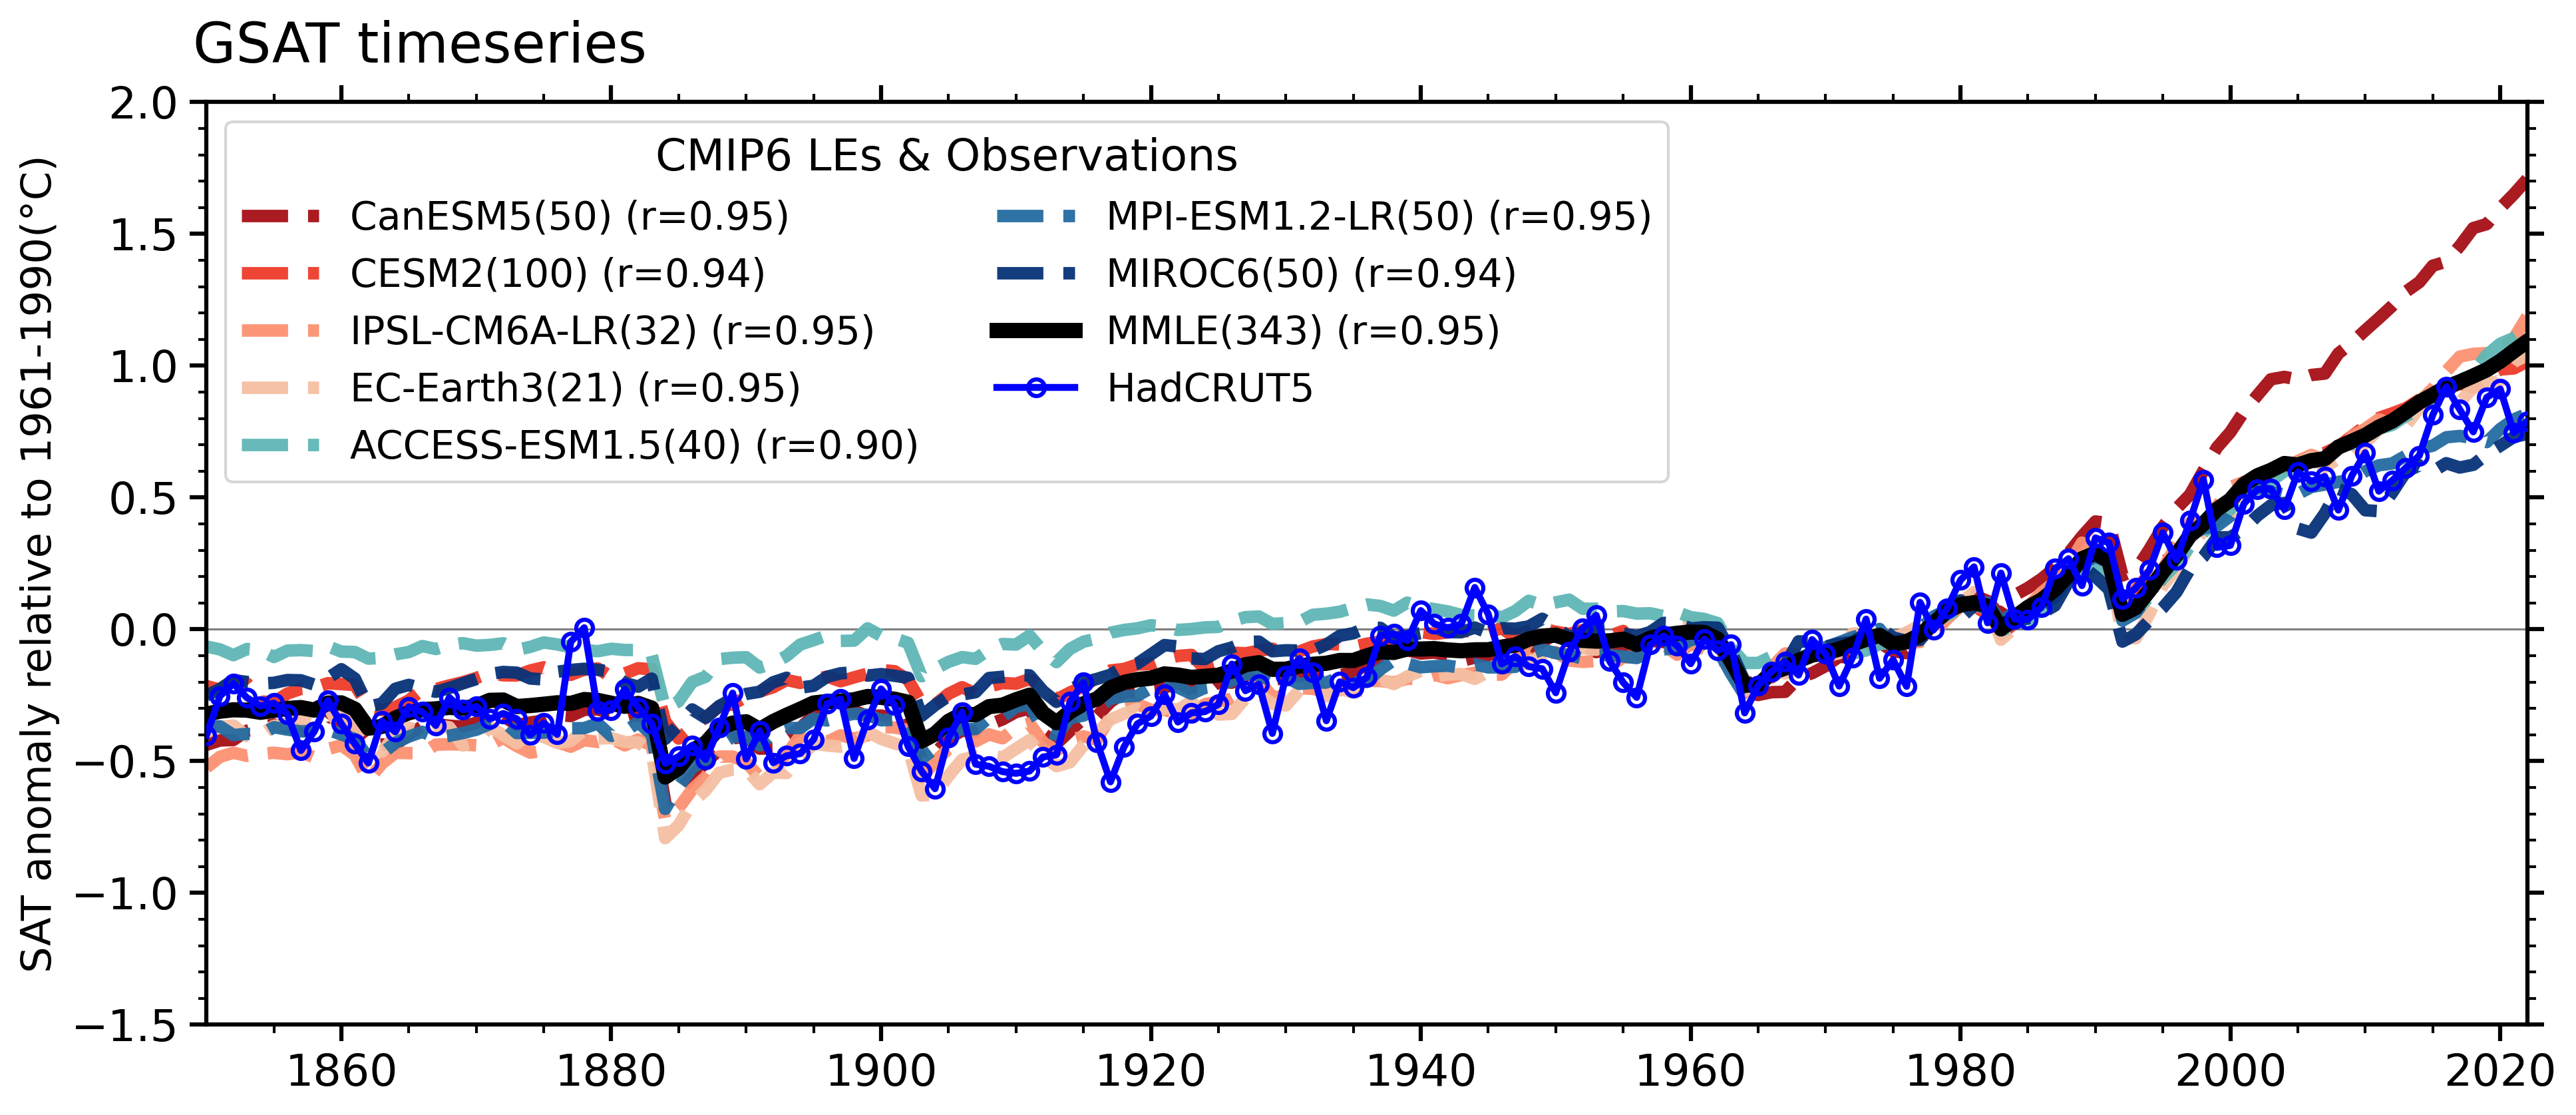

In [61]:
# subplot b: model simulated GSAT timeseries in each SMILEs and MMEM 1850-2022
# plot the GMSAT timeseries
set_science_advances_style()

fig2, ax2 = plt.subplots(figsize=(15, 6))
plt.plot([xmin,xmax],[0,0], color='grey', linestyle='-', linewidth=0.75)
# seven lines for six SMILEs and one MMEM with correlation coefficients
corr_ts = {
    "CanESM5(50)": 0.95,
    "CESM2(100)": 0.94, 
    "IPSL-CM6A-LR(32)": 0.95, 
    "EC-Earth3(21)": 0.95, 
    "ACCESS-ESM1.5(40)": 0.90, 
    "MPI-ESM1.2-LR(50)": 0.95,
    "MIROC6(50)": 0.94,
    "MMLE(343)": 0.95
}

ax2.plot(x, CanESM_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[0]], 
         label=f"{model_names[0]} (r={corr_ts['CanESM5(50)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, CESM2_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[1]], 
         label=f"{model_names[1]} (r={corr_ts['CESM2(100)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, IPSL_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[2]], 
         label=f"{model_names[2]} (r={corr_ts['IPSL-CM6A-LR(32)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, EC_Earth_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[3]], 
         label=f"{model_names[3]} (r={corr_ts['EC-Earth3(21)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, ACCESS_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[4]], 
         label=f"{model_names[4]} (r={corr_ts['ACCESS-ESM1.5(40)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, MPI_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[5]], 
         label=f"{model_names[5]} (r={corr_ts['MPI-ESM1.2-LR(50)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, MIROC_GMSAT_annual_ENS['tas'], color=RGB_dict[model_names[6]], 
         label=f"{model_names[6]} (r={corr_ts['MIROC6(50)']:.2f})", linewidth=lw_model,
         linestyle= '--', alpha=0.95)
ax2.plot(x, MMEM_GMSAT_annual_ENS['tas'], color=RGB_dict['MMLE'], 
         label=f"MMLE(343) (r={corr_ts['MMLE(343)']:.2f})", linewidth=5.5)

# ax2.plot(x, tas_NOAA_annual_global['tas'],   linestyle='-', markerfacecolor='none', markeredgewidth=1.5, label='NOAAGlobalTemp', color=c_obs, linewidth=lw_obs, zorder=5)
ax2.plot(x, tas_HadCRUT5_annual_global['tas'], marker='o',linestyle='-', markerfacecolor='none', markeredgewidth=1.5, label='HadCRUT5', color=c_obs_1, linewidth=lw_obs, zorder=4)
# ax2.plot(x, tas_Berkeley_annual_global['tas'], marker='o', linestyle='-', markerfacecolor='none', markeredgewidth=1.5, label='BerkeleyEarth', color=c_obs_2, linewidth=lw_obs, zorder=3)
# make the frame thicker
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)
# Add legend
# plt.axvspan(1950, 2022, alpha=0.25, color='grey')
# plt.text(1950, 2.05, '1950-2022', fontsize=18)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# make both the major and minor ticks larger
ax2.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
ax2.tick_params(axis='both', which='minor', direction='out', length=3, width=1.0)

plt.ylabel('SAT anomaly relative to 1961-1990(°C)', fontsize=15)
legend = plt.legend(loc='upper left', fontsize=14, ncol=2, title='CMIP6 LEs & Observations', title_fontsize='16')
# plt.text(1843, 2.15, 'A', fontsize=22, fontweight='bold', ha='left')
plt.text(1849, 2.15,'GSAT timeseries', fontsize=20)
figure_output = '/work/mh0033/m301036/OBS_LPS_revision/script/Revision_check/figures/'
plt.savefig(figure_output+"FIGURE_S1_OBS_GAST.png", dpi=300, bbox_inches='tight')
plt.savefig(figure_output+"FIGURE_S1_OBS_GAST.pdf", dpi=300, bbox_inches='tight')

plt.show()